# Install Dependencies

In [ ]:
!pip install openai

In [ ]:
!pip install transformers torch scikit-learn matplotlib seaborn

# Import Dependencies

In [ ]:
import openai
from openai import OpenAI
from google.colab import userdata
from IPython.display import Markdown as md
import pandas as pd
import json


In [ ]:

client = OpenAI(
  api_key=userdata.get('OPENAI_API_KEY')
)


# Advising Guideline
This will be used in later prompts for classification and question answering.

In [ ]:
advising_guidelines = '''
### **Student Guidelines**

As a Computer Science major at BC, you have two program options: the Bachelor of Arts (B.A.) in CS or the Bachelor of Science (B.S.) in CS. These programs have some differences that you can explore on the department's website [cs.bc.edu](https://www.bc.edu/content/bc-web/schools/mcas/departments/computer-science.html). To summarize, the B.S. program has more stringent science and math requirements and includes a course on the social and ethical aspects of computing, along with [two science courses](https://www.bc.edu/bc-web/academics/sites/university-catalog/undergraduate/mcas/computer-science.html) with labs. More details can be found in the [academics page](https://www.bc.edu/content/bc-web/schools/morrissey/departments/computer-science/academics/programs.html) on the department website.

Regardless of your program, you will need to complete MATH1103 (Calculus II for Science Majors) unless you have a Calculus BC AP grade above 4\. If you're in the classes of 2023 or 2024, you can meet this requirement with "non-science" Calculus II (MATH1101). For the class of 2028 and beyond, students pursuing a BA should also take Linear Algebra.

Your primary goal as a student is to stay on track toward completing your degree at BC. Your academic advisor can provide guidance on course selection and career options. If you're pursuing a double major, you'll receive specific advising for your other major, but your main advisor will assist you with general university [Core Curriculum requirements](https://www.bc.edu/content/bc-web/schools/morrissey/undergraduate/core-curriculum/core-requirements.html) and [language proficiency](https://www.bc.edu/content/bc-web/academics/sites/university-catalog/policies-procedures/undergraduate-academic-regulations.html#tab-language_proficiency_requirements). Please check out the [student FAQ](https://www.bc.edu/content/bc-web/schools/morrissey/undergraduate/core-curriculum/student-faq.html) on the Core Curriculum website. Also, make sure to check out other [undergraduate academic regulations](https://www.bc.edu/bc-web/academics/sites/university-catalog/policies-procedures.html.html#tab-undergraduate_academic_regulations).

You won't be able to register without discussing your courses with your advisor. Review your course history before your registration advising meeting. During your advising meeting, discuss your academic progress and future options. Make sure to ask questions about requirements, including University Core, Language Proficiency, and CS major-specific requirements.

If you're considering placing out of CS1, it requires departmental approval. Usually, a score of 5 on the CS AP course counts as CS1 but doesn't grant equivalent credits. If you are in this situation, please contact the department's director of undergraduate studies ([Prof. Maira Samary](https://www.bc.edu/bc-web/schools/morrissey/departments/computer-science/people/faculty-directory/maira-samary.html)). For elective courses, be aware of prerequisites as not meeting them may result in enrollment issues. You can also consult the [FAQs at the Academics link on the department's website](https://www.bc.edu/content/bc-web/schools/mcas/departments/computer-science/academics/faq.html).

Generally, the sooner students can complete the required CS courses, the better. Logic and Computation (L\&C) should be taken before Randomness and Computation (R\&C). L\&C must be completed before Algorithms; R\&C can be taken concurrently with Algorithms, though taking it beforehand is preferable.

Many BC students, including CS majors, study abroad for a semester during their junior year. Pre-approval for courses to count toward your major is crucial. Finding exact matches for required courses can be challenging, especially in Europe. One reason for this is that some undergraduate programs in Europe only last 3 years; another is simply that levels of rigor differ between institutions. All courses abroad must be approved by the Undergraduate Program Director (Prof. Maira Samary: [marquemo@bc.edu](mailto:marquemo@bc.edu)), and the required form must be signed by the Undergraduate Program Director.

Students double majoring or minoring in CS and Math can take Introduction to Abstract Math as a substitute for Logic and Computation, and Probability as a substitute for Randomness and Computation. For these courses to fulfill these requirements they must fill out the “Degree Audit – Course Substitution Waiver” form that can be found [here](https://www.bc.edu/bc-web/offices/student-services/registrar/academic-forms.html).

Students can double count courses in the major and in the minor, but there is a limit. Each major needs at least 27 unique credits and the minor needs at least 15 unique credits.

Keep in mind that you can't take courses pass/fail if they count towards your major or minor, even if the course is a co-requisite like Calculus II or the Science courses for the BS. Additionally, the Computer Science Department doesn't accept any Woods College courses. The only CSOM courses accepted are ECON338201 Introduction to Computational Investing as a 3000-level elective and ECON338901 Machine Learning for Economics as a 2000-level elective.

If you're interested in research, you can collaborate with a CS faculty member for an independent study course that counts as a 3000-level elective. However, additional independent study credits beyond the first three only count as Morrissey elective credits, not toward the CS major.

For additional support resources, please refer to [this website](https://sites.google.com/bc.edu/mcasadvising/support-resources).
'''

<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_17079/4104930603.py:6: SyntaxWarning: invalid escape sequence '\.'
  Regardless of your program, you will need to complete MATH1103 (Calculus II for Science Majors) unless you have a Calculus BC AP grade above 4\. If you're in the classes of 2023 or 2024, you can meet this requirement with "non-science" Calculus II (MATH1101). For the class of 2028 and beyond, students pursuing a BA should also take Linear Algebra.


In [ ]:
def answer_advising_question(question):

  response_prompt = f'''
    Advising Guidelines: {advising_guidelines}

    Based on the advising guidelines, please provide a concise and helpful answer to the following question. If the question is not relevant to the provided guidelines, please respond with "I cannot answer this question based on the provided advising guidelines."

    Question: {question}
  '''

  response = client.responses.create(
      model='gpt-5-nano',
      input =response_prompt
  )

  return response.output_text

In [ ]:
sample_question = "What are the main differences between the B.A. and B.S. programs in Computer Science at BC?"
response = answer_advising_question(sample_question)
print(f"Question: {sample_question}")
print(f"LLM Answer: {response}")

Question: What are the main differences between the B.A. and B.S. programs in Computer Science at BC?
LLM Answer: Here are the main differences:

- Science and math requirements:
  - B.S.: More stringent science and math requirements.
  - B.A.: Generally fewer science/math requirements.

- Required content:
  - B.S.: Includes a course on the social and ethical aspects of computing plus two science courses with labs.
  - B.A.: Does not require the ethics course or the two lab-based science courses (as part of CS-specific requirements).

- Linear Algebra for BA:
  - Class of 2028 and beyond: BA students are required to take Linear Algebra.

Tip: For exact details and any year-specific changes, see the department pages linked in the guidelines. If you’re deciding now, the B.S. is typically the more math/science heavy option with additional ethics content, while the B.A. is more flexible.


# Load Benchmark Dataset
Here load your dataset.

In [ ]:
df = pd.read_csv('advising_data.csv')

# Display the DataFrame
df.head()

,Question,Relevancy,Ground Truth Response
0,What’s the difference between the B.A. and B.S...,Advising,The B.S. has additional science and math requi...
1,Do I need to complete MATH1103 for the B.A. in...,Advising,"Yes, MATH1103 (Calculus II for Science Majors)..."
2,Can I take Calculus II pass/fail if it's requi...,Advising,"No, courses that count toward your major canno..."
3,Is Logic and Computation required before takin...,Advising,"Yes, Logic and Computation must be completed b..."
4,How can I get my study abroad courses approved...,Advising,All courses abroad must be approved by the Und...


In [ ]:
# display head of non advising questions
df[df['Relevancy'] == 'Not Advising'].head()

,Question,Relevancy,Ground Truth Response
33,Where is the CS department located?,Not Advising,This is unrelated to advising.
34,What events are hosted for CS majors?,Not Advising,This is unrelated to academic advising.
35,Are there study spaces reserved for CS students?,Not Advising,This is unrelated to academic advising.
36,Can you recommend any CS clubs on campus?,Not Advising,This question does not relate to advising.
37,Where is the nearest parking lot to the CS bui...,Not Advising,This is not relevant to academic advising.


# Evaluate Relevancy
In this section, we are using the LLM to classify the question whether it's relevant or irrelevant based on the advising guideline

In [ ]:
# define pydantic to store classification result (Advising or Not Advising)
from pydantic import BaseModel, Field
from typing import Literal

class ClassificationResult(BaseModel):
  relevancy: Literal['Advising', 'Not Advising'] = Field(description='Is the question relevant to advising?')

# loop over df and for each question
for index, row in df.iterrows():
  question = row['Question']

  classification_prompt = f'''
    Advising Guidelines: {advising_guidelines}

    Based on the advising guidelines above, determine if the following question is relevant to advising or not.

    Question: {question}
  '''

  # Using the user-provided structured output pattern
  response = client.responses.parse(
      model='gpt-4o-mini',
      input=classification_prompt,
      text_format=ClassificationResult
  )

  # Save the result from the parsed output
  df.at[index, 'Predicted Relevancy'] = response.output_parsed.relevancy

# display the output
df.head()

,Question,Relevancy,Ground Truth Response,Predicted Relevancy
0,What’s the difference between the B.A. and B.S...,Advising,The B.S. has additional science and math requi...,Advising
1,Do I need to complete MATH1103 for the B.A. in...,Advising,"Yes, MATH1103 (Calculus II for Science Majors)...",Advising
2,Can I take Calculus II pass/fail if it's requi...,Advising,"No, courses that count toward your major canno...",Not Advising
3,Is Logic and Computation required before takin...,Advising,"Yes, Logic and Computation must be completed b...",Advising
4,How can I get my study abroad courses approved...,Advising,All courses abroad must be approved by the Und...,Advising


## Compute Precision, Recall, F1-Score, Confusion Matrix
The following code will compute peformance metrics along with the confusion matrix diagram.

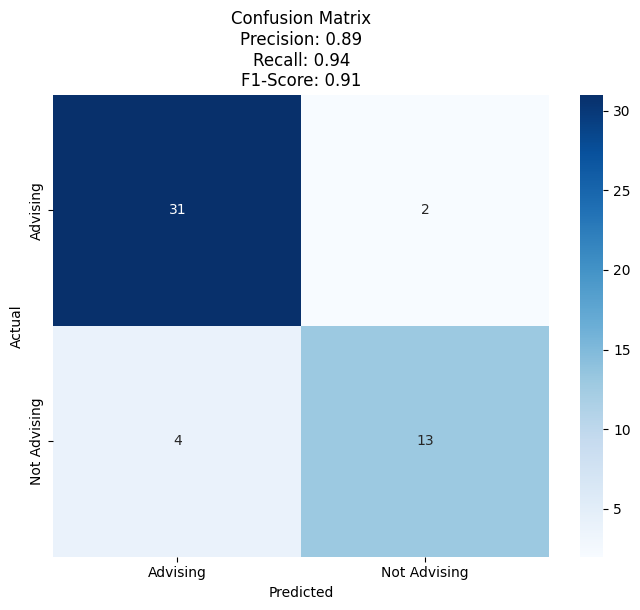

In [ ]:
# Compute Precision, Recall, F1-Score, Confusion Matrix
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate precision, recall, and F1-score
precision = precision_score(df['Relevancy'], df['Predicted Relevancy'], pos_label='Advising')
recall = recall_score(df['Relevancy'], df['Predicted Relevancy'], pos_label='Advising')
f1 = f1_score(df['Relevancy'], df['Predicted Relevancy'], pos_label='Advising')

# Compute Confusion Matrix
conf_matrix = confusion_matrix(df['Relevancy'], df['Predicted Relevancy'], labels=['Advising', 'Not Advising'])

# Display Results
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Advising', 'Not Advising'], yticklabels=['Advising', 'Not Advising'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix\nPrecision: {precision:.2f}\nRecall: {recall:.2f}\nF1-Score: {f1:.2f}')
plt.show()



In [ ]:
# compute accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(df['Relevancy'], df['Predicted Relevancy'])
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.88


#  Evaluate Response Quality
Here, we will generate LLM responses to the advising quesitons and evlauate the quality of the responses agains ground truth references.

Fill out the TODO parts.

## Step 1. Generate LLM Responses
We will generate two versions of LLM responses to compare which one is better using performance metrics against ground truth references.

### Version 1: Using Advising guidelines

In [ ]:
# loop through df
for index, row in df.iterrows():
  question = row['Question']

  # Write your response generation prompt (use advising guidelines above)
  response_prompt = f'''
    Advising Guidelines: {advising_guidelines}

    Based on the advising guidelines, please generate one sentence concise response to the following question. If the question is not relevant to advising, please respond with "Not relevant to advising.".

    Question: {question}
  '''

  # Generate a LLM response using the latest API
  response = client.responses.create(
      model='gpt-4o-mini',
      input=response_prompt
  )

  # Save LLM Response from output_text as a new column
  df.at[index, 'LLM Response V1'] = response.output_text

df.head()

,Question,Relevancy,Ground Truth Response,Predicted Relevancy,LLM Response V1
0,What’s the difference between the B.A. and B.S...,Advising,The B.S. has additional science and math requi...,Advising,The B.S. program has more stringent science an...
1,Do I need to complete MATH1103 for the B.A. in...,Advising,"Yes, MATH1103 (Calculus II for Science Majors)...",Advising,"Yes, you need to complete MATH1103 (Calculus I..."
2,Can I take Calculus II pass/fail if it's requi...,Advising,"No, courses that count toward your major canno...",Not Advising,"No, you can't take Calculus II pass/fail if it..."
3,Is Logic and Computation required before takin...,Advising,"Yes, Logic and Computation must be completed b...",Advising,"Yes, Logic and Computation is required before ..."
4,How can I get my study abroad courses approved...,Advising,All courses abroad must be approved by the Und...,Advising,To get your study abroad courses approved for ...


### Version 2: Without using Advising Guidelines

In [ ]:
# loop through df
for index, row in df.iterrows():
  question = row['Question']

   # TODO: Write your response generation prompt without using advising guidelines
  response_prompt = f'''
    Please generate one sentence concise response to the following question about Boston College Computer Science. If the question is not relevant to advising, please respond with "Not relevant to advising.".

    Question: {question}
  '''

  # Generate a LLM response using the latest API
  response = client.responses.create(
      model="gpt-4o-mini",
      input=response_prompt
  )

  # Save LLM Response from output_text as a new column
  df.at[index, "LLM Response V2"] = response.output_text

df.head()

,Question,Relevancy,Ground Truth Response,Predicted Relevancy,LLM Response V1,LLM Response V2
0,What’s the difference between the B.A. and B.S...,Advising,The B.S. has additional science and math requi...,Advising,The B.S. program has more stringent science an...,The B.A. in Computer Science focuses more on a...
1,Do I need to complete MATH1103 for the B.A. in...,Advising,"Yes, MATH1103 (Calculus II for Science Majors)...",Advising,"Yes, you need to complete MATH1103 (Calculus I...","Yes, MATH1103 is a requirement for the B.A. in..."
2,Can I take Calculus II pass/fail if it's requi...,Advising,"No, courses that count toward your major canno...",Not Advising,"No, you can't take Calculus II pass/fail if it...","No, you cannot take Calculus II pass/fail if i..."
3,Is Logic and Computation required before takin...,Advising,"Yes, Logic and Computation must be completed b...",Advising,"Yes, Logic and Computation is required before ...","Yes, Logic and Computation is a prerequisite f..."
4,How can I get my study abroad courses approved...,Advising,All courses abroad must be approved by the Und...,Advising,To get your study abroad courses approved for ...,Contact your academic advisor and provide the ...


## Step 2. Evaluate the Response Quality Automatically using LLM

### Version 1 Evaluation

In [ ]:
# Note: It's better to use another model or higher-order model to evaluate the lower-model response but for the price's sake we will use the same GPT4o-mini model

# write a pydantic with integer containing one of 1,2,3,4 5
class Rating(BaseModel):
  rating: Literal[1,2,3,4,5] = Field(description='Rate the coherence of the LLM response compared to the ground truth reference on a scale of 1-5.')

# loop through df
for index, row in df.iterrows():
  llm_response = row['LLM Response V1']
  ground_truth_response = row['Ground Truth Response']

  # Construct an evaluation prompt
  response_prompt = f'''

    Rate the coherence of the LLM response compared to the ground truth reference on a scale of 1-5.

    5 – Excellent: The response is fully correct, highly helpful, and relevant.
    4 – Good: The response is correct and generally helpful, with minor improvements needed.
    3 – Adequate: The response is partially correct/helpful but could be improved.
    2 – Poor: The response is mostly incorrect or not very helpful.
    1 – Unsatisfactory: The response is irrelevant or entirely unhelpful.

    Grond Truth Reference: {ground_truth_response}
    LLM Response: {llm_response}
  '''
  # Ask LLM to rate the quality of each LLM response using the latest structured output API
  response = client.responses.parse(
      model='gpt-5-mini',
      input=response_prompt,
      text_format=Rating
  )
  # Save LLM's rating as a new column
  df.at[index, 'LLM V1 Rating'] = response.output_parsed.rating

df.head()

,Question,Relevancy,Ground Truth Response,Predicted Relevancy,LLM Response V1,LLM Response V2,LLM V1 Rating
0,What’s the difference between the B.A. and B.S...,Advising,The B.S. has additional science and math requi...,Advising,The B.S. program has more stringent science an...,The B.A. in Computer Science focuses more on a...,5.0
1,Do I need to complete MATH1103 for the B.A. in...,Advising,"Yes, MATH1103 (Calculus II for Science Majors)...",Advising,"Yes, you need to complete MATH1103 (Calculus I...","Yes, MATH1103 is a requirement for the B.A. in...",5.0
2,Can I take Calculus II pass/fail if it's requi...,Advising,"No, courses that count toward your major canno...",Not Advising,"No, you can't take Calculus II pass/fail if it...","No, you cannot take Calculus II pass/fail if i...",5.0
3,Is Logic and Computation required before takin...,Advising,"Yes, Logic and Computation must be completed b...",Advising,"Yes, Logic and Computation is required before ...","Yes, Logic and Computation is a prerequisite f...",5.0
4,How can I get my study abroad courses approved...,Advising,All courses abroad must be approved by the Und...,Advising,To get your study abroad courses approved for ...,Contact your academic advisor and provide the ...,5.0


### Version 2 Evaluation

In [ ]:
# Note: It's better to use another model or higher-order model to evaluate the lower-model  response but for the price's sake we will use the same GPT4o-mini model

# write a pydantic with integer containing one of 1,2,3,4 5
class Rating(BaseModel):
  rating: Literal[1,2,3,4,5] = Field(description='Rate the coherence of the LLM response compared to the ground truth reference on a scale of 1-5.')

# loop through df
for index, row in df.iterrows():
  llm_response = row['LLM Response V2']
  ground_truth_response = row['Ground Truth Response']

  # Construct an evaluation prompt
  response_prompt = f'''

    Rate the coherence of the LLM response compared to the ground truth reference on a scale of 1-5.

    5 – Excellent: The response is fully correct, highly helpful, and relevant.
    4 – Good: The response is correct and generally helpful, with minor improvements needed.
    3 – Adequate: The response is partially correct/helpful but could be improved.
    2 – Poor: The response is mostly incorrect or not very helpful.
    1 – Unsatisfactory: The response is irrelevant or entirely unhelpful.

    Grond Truth Reference: {ground_truth_response}
    LLM Response: {llm_response}
  '''
  # Ask LLM to rate the quality of each LLM response using the latest structured output API
  response = client.responses.parse(
      model='gpt-5-mini',
      input=response_prompt,
      text_format=Rating
  )
  # Save LLM's rating as a new column
  df.at[index, 'LLM V2 Rating'] = response.output_parsed.rating

df.head()

,Question,Relevancy,Ground Truth Response,Predicted Relevancy,LLM Response V1,LLM Response V2,LLM V1 Rating,LLM V2 Rating
0,What’s the difference between the B.A. and B.S...,Advising,The B.S. has additional science and math requi...,Advising,The B.S. program has more stringent science an...,The B.A. in Computer Science focuses more on a...,5.0,3.0
1,Do I need to complete MATH1103 for the B.A. in...,Advising,"Yes, MATH1103 (Calculus II for Science Majors)...",Advising,"Yes, you need to complete MATH1103 (Calculus I...","Yes, MATH1103 is a requirement for the B.A. in...",5.0,3.0
2,Can I take Calculus II pass/fail if it's requi...,Advising,"No, courses that count toward your major canno...",Not Advising,"No, you can't take Calculus II pass/fail if it...","No, you cannot take Calculus II pass/fail if i...",5.0,5.0
3,Is Logic and Computation required before takin...,Advising,"Yes, Logic and Computation must be completed b...",Advising,"Yes, Logic and Computation is required before ...","Yes, Logic and Computation is a prerequisite f...",5.0,5.0
4,How can I get my study abroad courses approved...,Advising,All courses abroad must be approved by the Und...,Advising,To get your study abroad courses approved for ...,Contact your academic advisor and provide the ...,5.0,3.0


## Compare Version 1 vs Version 2
Version 1 should be more accurate as it uses the advising guidelines

In [ ]:
# compare average scroes of LLM V1 Rating and V2 Rating
print(f"Average LLM V1 Rating: {df['LLM V1 Rating'].mean()}")
print(f"Average LLM V2 Rating: {df['LLM V2 Rating'].mean()}")

Average LLM V1 Rating: 4.28
Average LLM V2 Rating: 3.1


## Step 3. Evaluate the Response Quality Manually
We want to ensure that our LLM-based evaluation aligns with human judgment. We manually rate the responses and see how our scores correlate with the LLM-generated scores.

In reality, rather than performing this manual evaluation for every entry, we typically just evaluate a sample for verification purposes.

Create a new column named 'Human Rating V1' and add your own rating for the Version 1 response. Feel free to do the same for Version 2, as this provides additional evidence for the reliability of the LLM-based evaluation.


In [ ]:
# 1) Use the interactive sheet to add a new column with human ratings on the same scale
# from google.colab import sheets
# sheet = sheets.InteractiveSheet(df=df)

# 2) Or put the numbers manually
import random
# df['Human V1 Rating'] = [ your ratings here ]
# df['Human V2 Rating'] = [ your ratings here ]
df['Human V1 Rating'] = [random.randint(4, 5) for _ in range(len(df))]
df['Human V2 Rating'] = [random.randint(2, 3) for _ in range(len(df))]

# 3) Or export the df as a csv and edit it in your own spreadsheet
# df.to_csv('advising_data_with_ratings.csv', index=False)
# and Load it back
# df = pd.read_csv('advising_data_with_ratings.csv')

df.head()

,Question,Relevancy,Ground Truth Response,Predicted Relevancy,LLM Response V1,LLM Response V2,LLM V1 Rating,LLM V2 Rating,Human V1 Rating,Human V2 Rating
0,What’s the difference between the B.A. and B.S...,Advising,The B.S. has additional science and math requi...,Advising,The B.S. program has more stringent science an...,The B.A. in Computer Science focuses more on a...,5.0,3.0,4,3
1,Do I need to complete MATH1103 for the B.A. in...,Advising,"Yes, MATH1103 (Calculus II for Science Majors)...",Advising,"Yes, you need to complete MATH1103 (Calculus I...","Yes, MATH1103 is a requirement for the B.A. in...",5.0,3.0,5,2
2,Can I take Calculus II pass/fail if it's requi...,Advising,"No, courses that count toward your major canno...",Not Advising,"No, you can't take Calculus II pass/fail if it...","No, you cannot take Calculus II pass/fail if i...",5.0,5.0,4,3
3,Is Logic and Computation required before takin...,Advising,"Yes, Logic and Computation must be completed b...",Advising,"Yes, Logic and Computation is required before ...","Yes, Logic and Computation is a prerequisite f...",5.0,5.0,4,2
4,How can I get my study abroad courses approved...,Advising,All courses abroad must be approved by the Und...,Advising,To get your study abroad courses approved for ...,Contact your academic advisor and provide the ...,5.0,3.0,5,3


###  Export the data frame to a CSV file (for Submission)

In [ ]:
# export df to csv (you can see the generated file in the Files tab on the side panel.)
df.to_csv('advising_data_with_ratings.csv')


## Step 4. Compute Alignment Between Human and LLM Ratings
This alignment score will tell you whether LLM-based evaluation is comparable to human-based evaluation.

In [ ]:
# Compute the Kendall's tau alignment score
from scipy.stats import kendalltau

kendalltau(df['LLM V1 Rating'], df['Human V1 Rating'])

SignificanceResult(statistic=np.float64(-0.016312931526714928), pvalue=np.float64(0.9037810177135053))

In [ ]:
# Compute the Spearman's correlation
from scipy.stats import spearmanr

spearmanr(list(df['LLM V2 Rating']), list(df['Human V2 Rating']))

SignificanceResult(statistic=np.float64(-0.09470248738373976), pvalue=np.float64(0.5129938282961626))

# Other Metrics

In the following examples, you can try computing other metrics. Keep in mind that you can't compare these different metrics as they are derived differently. You can test different promptings to see if the score improves within each metric not across different metrics.

# Bert Score


In [ ]:
!pip install bert-score


## Version 1

In [ ]:
from bert_score import score

P, R, F1 = score(list(df['Ground Truth Response']), list(df['LLM Response V1']), lang="en", verbose=True)
print(f"Precision: {P.mean():.3f}")
print(f"Recall: {R.mean():.3f}")
print(f"F1: {F1.mean():.3f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 55.24 seconds, 0.91 sentences/sec
Precision: 0.923
Recall: 0.927
F1: 0.924


## Version 2

In [ ]:
P, R, F1 = score(list(df['Ground Truth Response']), list(df['LLM Response V2']), lang="en", verbose=True)
print(f"Precision: {P.mean():.3f}")
print(f"Recall: {R.mean():.3f}")
print(f"F1: {F1.mean():.3f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 41.83 seconds, 1.20 sentences/sec
Precision: 0.886
Recall: 0.890
F1: 0.888


# BLEU

In [ ]:
!pip install nltk

In [ ]:

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Define the BLEU scoring function
def compute_bleu(reference, candidate):
    # Use smoothing to avoid zero scores for short sentences
    smooth = SmoothingFunction().method1
    return sentence_bleu([reference.split()], candidate.split(), smoothing_function=smooth)

## Version 1

In [ ]:


# Apply the BLEU scoring function to each row
bleu_score = df.apply(lambda row: compute_bleu(row['Ground Truth Response'], row['LLM Response V1']), axis=1)

# Calculate the average BLEU score
average_bleu = bleu_score.mean()
print("Average BLEU score:", average_bleu)


Average BLEU score: 0.20305535126805807


## Version 2

In [ ]:


# Apply the BLEU scoring function to each row
bleu_score = df.apply(lambda row: compute_bleu(row['Ground Truth Response'], row['LLM Response V2']), axis=1)

# Calculate the average BLEU score
average_bleu = bleu_score.mean()
print("Average BLEU score:", average_bleu)


Average BLEU score: 0.04180252927897118


# ROUGE
You can't compare ROUGE to BLEU or BERT Scores.

In [ ]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=4275b56b1a8344598bd0a2c66e8e6a01af16c88cb6d334252279fb13722b6340
  Stored in directory: /root/.cache/pip/wheels/5f/dd/89/461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score


In [ ]:
from rouge_score import rouge_scorer

# go through each row in a data frame  and apply a function that returns a value and aggregate to compute an average
def scoring(reference, candidate):
  scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
  scores = scorer.score(reference, candidate)
  return scores

## Version 1

In [ ]:

rouge_scores = df.apply(lambda row: scoring(row['Ground Truth Response'], row['LLM Response V1']), axis=1)
# compute average of the apply


# Separate the scores and compute averages
rouge1_scores = [score['rouge1'].recall for score in rouge_scores]
rouge2_scores = [score['rouge2'].recall for score in rouge_scores]
rougeL_scores = [score['rougeL'].recall for score in rouge_scores]

# Calculate average scores
average_rouge1 = sum(rouge1_scores) / len(rouge1_scores)
average_rouge2 = sum(rouge2_scores) / len(rouge2_scores)
average_rougeL = sum(rougeL_scores) / len(rougeL_scores)

print("Average ROUGE-1 Recall:", average_rouge1)
print("Average ROUGE-2 Recall:", average_rouge2)
print("Average ROUGE-L Recall:", average_rougeL)



Average ROUGE-1 Recall: 0.5995352222596803
Average ROUGE-2 Recall: 0.36021568343936766
Average ROUGE-L Recall: 0.5349818375638808


## Version 2

In [ ]:

rouge_scores = df.apply(lambda row: scoring(row['Ground Truth Response'], row['LLM Response V2']), axis=1)
# compute average of the apply


# Separate the scores and compute averages
rouge1_scores = [score['rouge1'].recall for score in rouge_scores]
rouge2_scores = [score['rouge2'].recall for score in rouge_scores]
rougeL_scores = [score['rougeL'].recall for score in rouge_scores]

# Calculate average scores
average_rouge1 = sum(rouge1_scores) / len(rouge1_scores)
average_rouge2 = sum(rouge2_scores) / len(rouge2_scores)
average_rougeL = sum(rougeL_scores) / len(rougeL_scores)

print("Average ROUGE-1 Recall:", average_rouge1)
print("Average ROUGE-2 Recall:", average_rouge2)
print("Average ROUGE-L Recall:", average_rougeL)



Average ROUGE-1 Recall: 0.32870626638583295
Average ROUGE-2 Recall: 0.1246220323364286
Average ROUGE-L Recall: 0.28145520758910847
